In [1]:
from src import sph_cpp
from src.visualization import *
import matplotlib.pyplot as plt

### Define simulation parameters

In [2]:
res = 0.1
no_steps = 100
Lx = 5.0
Ly = 5.0
rho0 = 1.0
kappa = 1.2
v0 = 0.5
dt = 0.05
c_s = 1
beta = 0.07

inflow_factor = 0.1
outflow_factor = 0.1

central_radius = 1
boundary_width = 0.02
max_force = 1000

### Run simulation

In [3]:
params = sph_cpp.SimulationParams(
    res, no_steps, Lx, Ly, rho0, kappa, v0, dt, c_s, beta, central_radius, boundary_width, max_force, inflow_factor, outflow_factor
)

# Initialize ParticleList
particle_list = sph_cpp.ParticleList(params)

# Setup initial conditions
particle_list.init_grid()
particle_list.init_mass()
particle_list.init_vel()

# Run simulation
rerun_sim = True
if rerun_sim:
    particle_list.integrate()


Nx = int(Lx/res)
Ny = int(Ly/res)
init_particles = Nx*Ny
masses = params.rho0*params.Lx*params.Ly/params.init_particles

### Read data

In [4]:
positions, velocities, types = read_all_output("all_output.bin")

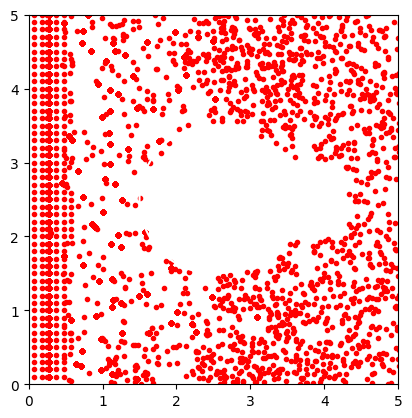

In [5]:
idx = 50

fig, ax = plt.subplots()
ax.set_xlim(0,float(params.Lx))
ax.set_ylim(0,float(params.Ly))
ax.set_aspect("equal")

# Plot particles
particles, = ax.plot(positions[idx][:,0], positions[idx][:,1], linestyle="None", marker=".", color="red")

# Plot central object
phi = np.linspace(0,2*np.pi,100)
ax.plot(params.Lx/2.0+params.central_radius*np.cos(phi), params.Ly/2.0+params.central_radius*np.sin(phi), color="white")

# Plot field
#x,y,vx,vy,v = get_velocity_grid(positions[idx], velocities[idx], masses, params)
#field = ax.pcolor(x,y,v)

plt.show()

### Create animation

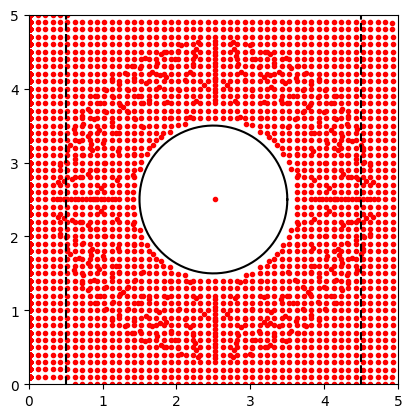

In [6]:
anim = animate(positions, velocities, params, masses, field_type="niets")

In [7]:
anim.save("figures/temp.mp4")

[4700 4742 4544 4489 4505 4445 4423 4413 4415 4411 4409 4409 4409 4409
 4407 4407 4407 4405 4404 4403 6602 6648 6644 6633 6623 6606 6542 6527
 6552 6520 6505 6478 6500 6476 6460 6431 6454 6388 6278 6256 8480 8511
 8405 8300 8137 7999 7724 7513 7435 7359 7245 7077 7106 7082 6971 6901
 6918 6895 6779 6742 8966 8985 8956 8839 8843 8739 8525 8428 8302 8216
 8107 8008 8019 7886 7857 7712 7726 7555 7522 7457 9546 9426 9355 9238
 9191 8959 8628 8365 8019 7992 7773 7702 7681 7662 7601 7495 7485 7376
 7220 6986]


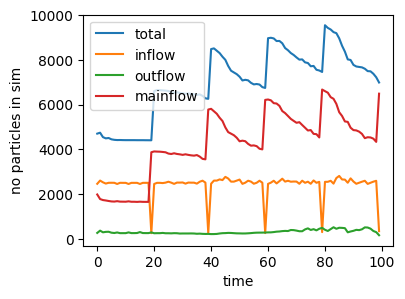

In [6]:
no_particles_in_sim = np.array([len(pos) for pos in positions])
no_inflow_particles = np.zeros(len(positions))
no_mainflow_particles = np.zeros(len(positions))
no_outflow_particles = np.zeros(len(positions))
for i in range(len(positions)):
    inflow_mask = positions[i][:,0]<(inflow_factor*Lx)
    mainflow_mask = (positions[i][:,0]>(inflow_factor*Lx)) & (positions[i][:,0]<(1-outflow_factor)*Lx)
    outflow_mask = positions[i][:,0]>(1-outflow_factor)*Lx
    no_inflow_particles[i] = len(positions[i][inflow_mask])
    no_mainflow_particles[i] = len(positions[i][mainflow_mask])
    no_outflow_particles[i] = len(positions[i][outflow_mask])


fig, ax = plt.subplots(figsize=(4,3))

ax.plot(no_particles_in_sim, label="total")
ax.plot(no_inflow_particles, label="inflow")
ax.plot(no_outflow_particles, label="outflow")
ax.plot(no_mainflow_particles, label="mainflow")
ax.set_xlabel("time")
ax.set_ylabel("no particles in sim")
ax.legend()
print(no_particles_in_sim)

1055


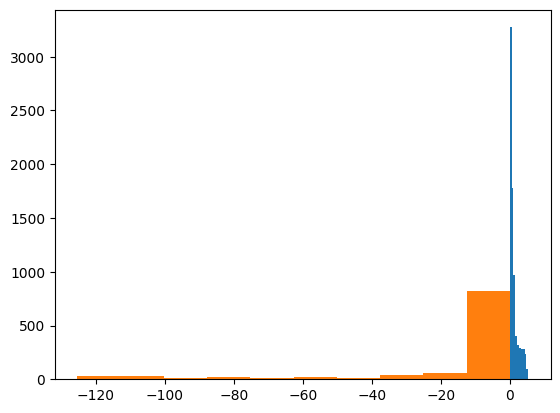

In [ ]:
idx = 50
fig, ax = plt.subplots()
ax.hist(positions[idx][:,0][positions[idx][:,0]>0])
ax.hist(positions[idx][:,0][positions[idx][:,0]<0])
print(len(positions[idx][:,0][positions[idx][:,0]<0]))

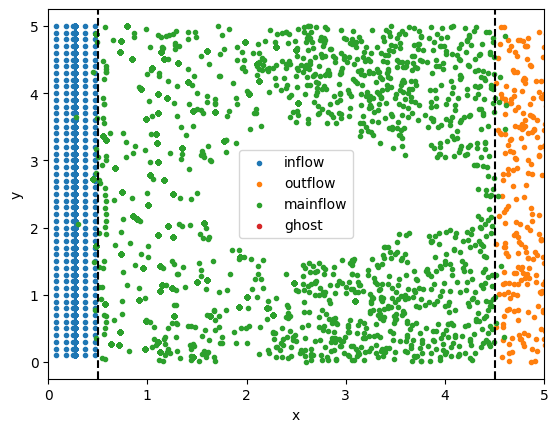

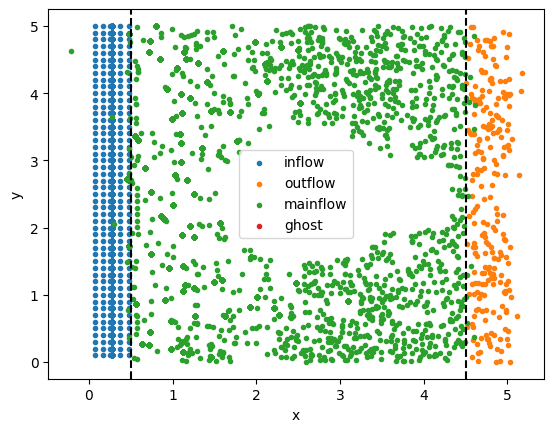

In [7]:
idx = 50



fig, ax = plt.subplots()
ax.scatter(positions[idx][:,0][types[idx]==0.0], positions[idx][:,1][types[idx]==0.0], marker='.', label="inflow")
ax.scatter(positions[idx][:,0][types[idx]==1.0], positions[idx][:,1][types[idx]==1.0], marker='.', label="outflow")
ax.scatter(positions[idx][:,0][types[idx]==2.0], positions[idx][:,1][types[idx]==2.0], marker='.', label="mainflow")
ax.scatter(positions[idx][:,0][types[idx]==3.0], positions[idx][:,1][types[idx]==3.0], marker='.', label="ghost")
ax.legend()
ax.set_xlim(0,5)
ax.axvline(inflow_factor*Lx, color="black", linestyle="--")
ax.axvline((1-outflow_factor)*Lx, color="black", linestyle="--")
ax.set_xlabel("x")
ax.set_ylabel("y")
#fig.savefig("figures/positions.png",dpi=300)
plt.show()

fig, ax = plt.subplots()
ax.scatter(positions[idx][:,0][types[idx]==0.0], positions[idx][:,1][types[idx]==0.0], marker='.', label="inflow")
ax.scatter(positions[idx][:,0][types[idx]==1.0], positions[idx][:,1][types[idx]==1.0], marker='.', label="outflow")
ax.scatter(positions[idx][:,0][types[idx]==2.0], positions[idx][:,1][types[idx]==2.0], marker='.', label="mainflow")
ax.scatter(positions[idx][:,0][types[idx]==3.0], positions[idx][:,1][types[idx]==3.0], marker='.', label="ghost")
ax.legend()
ax.axvline(inflow_factor*Lx, color="black", linestyle="--")
ax.axvline((1-outflow_factor)*Lx, color="black", linestyle="--")
ax.set_xlabel("x")
ax.set_ylabel("y")
#fig.savefig("figures/positions_all.png",dpi=300)
plt.show()

### Energy calculation

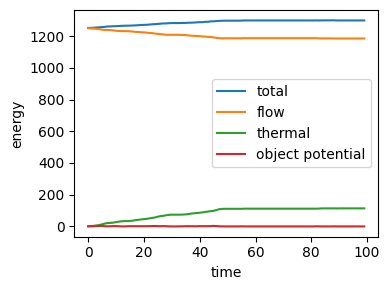

In [ ]:
E_total, E_bulk, E_rand, E_object = calculate_energies(positions, velocities, params, masses)

fig, ax = plt.subplots(figsize=(4,3))
ax.plot(E_total, label="total")
ax.plot(E_bulk, label="flow")
ax.plot(E_rand, label="thermal")
ax.plot(E_object, label="object potential")
ax.set_xlabel("time")
ax.set_ylabel("energy")
ax.legend()
fig.tight_layout()
fig.savefig("figures/energy_leapfrog.png", dpi=300)
plt.show()